In [1]:
# Setup

import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from gensim.models import Word2Vec
from sklearn.model_selection import GridSearchCV

# Load data
train_df = pd.read_parquet("/kaggle/input/datasets/konstantinosorfanos/training-data/train-00000-of-00001.parquet")
test_df  = pd.read_parquet("/kaggle/input/datasets/konstantinosorfanos/training-data/test-00000-of-00001.parquet")
sample   = pd.read_csv("/kaggle/input/competitions/ys-19-2026-assignment-1/sample_solution.csv")


# Used in W2V
def average_vectors(tokens, model, vector_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)


# Data overview
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nData types:\n", train_df.dtypes)
print("\nUnique labels:", train_df["clarity_label"].unique())
print("\nMissing values:\n", train_df.isnull().sum())
train_df.head()

Train shape: (3448, 20)
Test shape:  (308, 20)

Columns: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label']

Data types:
 title                    object
date                     object
president                object
url                      object
question_order            int64
interview_question       object
interview_answer         object
gpt3.5_summary           object
gpt3.5_prediction        object
question                 object
annotator_id             object
annotator1               object
annotator2               object
annotator3               object
inaudible                  bool
multiple_questions         bool
affirmative_questions      bool
index                     int64
clarity_label            object
evasion_lab

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer
3,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Are you worried about the meeting between Pre...,85,None,None,None,False,False,False,3,Ambivalent,Dodging
4,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. I can imagine. It is evening, I'd like to r...","Well, I hope I get to see Mr. Xi sooner than l...",The question consists of 3 parts:\n1. Is the P...,Question part: 1. Is the President's engagemen...,Is the President's engagement with Asian coun...,85,None,None,None,False,False,False,4,Clear Reply,Explicit


Label Distribution:
clarity_label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64


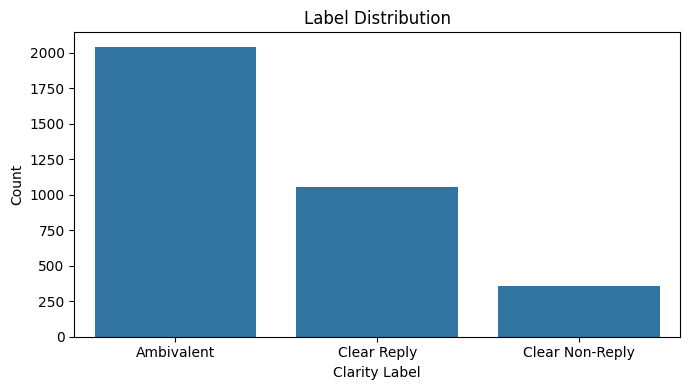


Question length stats:
count    3448.000000
mean       14.462007
std         8.833190
min         1.000000
25%         8.000000
50%        12.000000
75%        19.000000
max        80.000000
Name: question_len, dtype: float64

Answer length stats:
count    3448.000000
mean      293.572216
std       301.541101
min         1.000000
25%        56.000000
50%       207.000000
75%       440.000000
max      2117.000000
Name: answer_len, dtype: float64


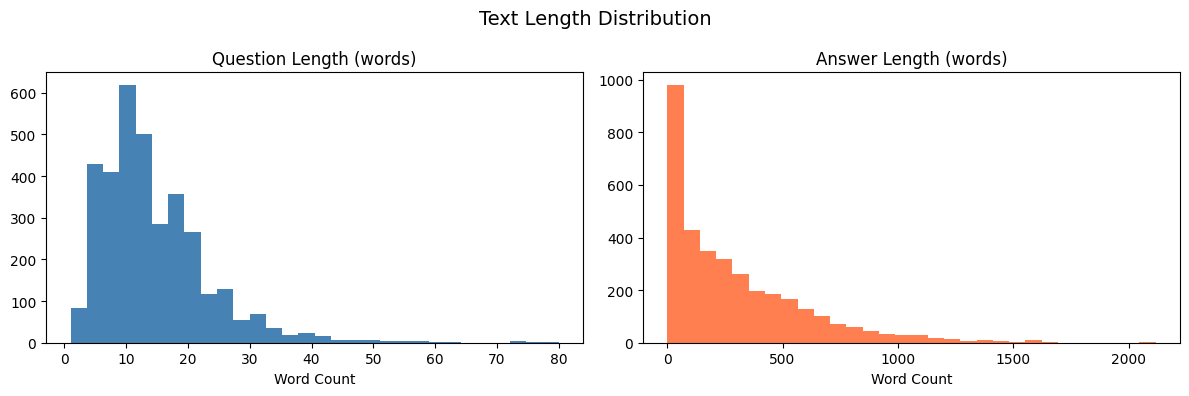

In [2]:
#EDA

# Label distribution
print("Label Distribution:")
print(train_df["clarity_label"].value_counts())

# Plot label distribution
plt.figure(figsize=(7,4))
sns.countplot(data=train_df, x="clarity_label", order=train_df["clarity_label"].value_counts().index)
plt.title("Label Distribution")
plt.xlabel("Clarity Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Text length stats
train_df["question_len"]  = train_df["question"].apply(lambda x: len(x.split()))
train_df["answer_len"]    = train_df["interview_answer"].apply(lambda x: len(x.split()))

print("\nQuestion length stats:")
print(train_df["question_len"].describe())
print("\nAnswer length stats:")
print(train_df["answer_len"].describe())

# Plot text lengths
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Text Length Distribution", fontsize=14)
axes[0].hist(train_df["question_len"], bins=30, color="steelblue")
axes[0].set_title("Question Length (words)")
axes[0].set_xlabel("Word Count")
axes[1].hist(train_df["answer_len"], bins=30, color="coral")
axes[1].set_title("Answer Length (words)")
axes[1].set_xlabel("Word Count")
plt.tight_layout()
plt.show()

In [3]:
# Preprocessing

# Merge
train_df["input_text"] = train_df["question"] + " [SEP] " + train_df["interview_answer"]
test_df["input_text"]  = test_df["question"]  + " [SEP] " + test_df["interview_answer"]

# Lowercase
train_df["input_text"] = train_df["input_text"].str.lower()
test_df["input_text"]  = test_df["input_text"].str.lower()

# Remove punctuation
train_df["input_text"] = train_df["input_text"].apply(lambda x: re.sub(r'[^\w\s]', '', x))
test_df["input_text"]  = test_df["input_text"].apply(lambda x: re.sub(r'[^\w\s]', '', x))

# Remove extra whitespace
train_df["input_text"] = train_df["input_text"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
test_df["input_text"]  = test_df["input_text"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# Encode labels
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["clarity_label"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Ambivalent': np.int64(0), 'Clear Non-Reply': np.int64(1), 'Clear Reply': np.int64(2)}


In [4]:
#Run 1

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,1), stop_words=None)
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf  = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_tfidf = LogisticRegression(C=1.0, max_iter=1000, class_weight=None, random_state=42) 
model_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Evaluation
y_pred_tfidf = model_tfidf.predict(X_val_tfidf)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

#Word2Vec

# Feature Extraction
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=1, seed=42) 

X_w2v = np.array([average_vectors(tokens, w2v_model, 100) for tokens in train_tokens])
X_test_w2v  = np.array([average_vectors(tokens, w2v_model, 100) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_w2v = LogisticRegression(C=1.0, max_iter=1000, class_weight=None, random_state=42)
model_w2v.fit(X_train_w2v, y_train_w2v)

# Evaluation
y_pred_w2v = model_w2v.predict(X_val_w2v)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

TF-IDF:
Accuracy:  0.6086956521739131
F1:  0.39861894698041667
Precision:  0.6236972903639569
Recall:  0.4013140552688575
W2V:
Accuracy:  0.6159420289855072
F1:  0.3940044713163952
Precision:  0.5231119287000722
Recall:  0.4057938817825823


In [5]:
#Run 2

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,1), stop_words=None)
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf  = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_tfidf = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42) 
model_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Evaluation
y_pred_tfidf = model_tfidf.predict(X_val_tfidf)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

#Word2Vec

# Feature Extraction
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=1, seed=42) 

X_w2v = np.array([average_vectors(tokens, w2v_model, 100) for tokens in train_tokens])
X_test_w2v  = np.array([average_vectors(tokens, w2v_model, 100) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

# Model Training
model_w2v = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
model_w2v.fit(X_train_w2v, y_train_w2v)

# Evaluation
y_pred_w2v = model_w2v.predict(X_val_w2v)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

TF-IDF:
Accuracy:  0.5449275362318841
F1:  0.49031315126628555
Precision:  0.4852827466035013
Recall:  0.4991157879575958
W2V:
Accuracy:  0.5130434782608696
F1:  0.45664125843210984
Precision:  0.44896392524259415
Recall:  0.49001176684792497


In [6]:
#Run 3

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,2), stop_words=None) 
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf  = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_tfidf = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42) 
model_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Evaluation
y_pred_tfidf = model_tfidf.predict(X_val_tfidf)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

#Word2Vec

# Feature Extraction
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=300, window=5, min_count=1, seed=42)

X_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in train_tokens])
X_test_w2v  = np.array([average_vectors(tokens, w2v_model, 300) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_w2v = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42) 
model_w2v.fit(X_train_w2v, y_train_w2v)

# Evaluation
y_pred_w2v = model_w2v.predict(X_val_w2v)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

TF-IDF:
Accuracy:  0.5797101449275363
F1:  0.5279641213792371
Precision:  0.5271105259140524
Recall:  0.5294527872211487
W2V:
Accuracy:  0.5144927536231884
F1:  0.45623563744849527
Precision:  0.4481075256214921
Recall:  0.4889057374933081


In [7]:
#Run 4

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,3), stop_words=None) 
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf  = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_tfidf = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42) 
model_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Evaluation
y_pred_tfidf = model_tfidf.predict(X_val_tfidf)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

#Word2Vec

# Feature Extraction
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=500, window=5, min_count=1, seed=42) 

X_w2v = np.array([average_vectors(tokens, w2v_model, 500) for tokens in train_tokens])
X_test_w2v  = np.array([average_vectors(tokens, w2v_model, 500) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_w2v = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42) 
model_w2v.fit(X_train_w2v, y_train_w2v)

# Evaluation
y_pred_w2v = model_w2v.predict(X_val_w2v)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

TF-IDF:
Accuracy:  0.5753623188405798
F1:  0.5094111575721266
Precision:  0.5202374948385757
Recall:  0.5022287034998899
W2V:
Accuracy:  0.5246376811594203
F1:  0.4641660374820786
Precision:  0.45648599834474807
Recall:  0.4944443765065234


In [8]:
# Run 5

import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

train_nostop = train_df["input_text"].apply(remove_stopwords)
test_nostop  = test_df["input_text"].apply(remove_stopwords)

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,2), stop_words=None)
X_tfidf = vectorizer.fit_transform(train_nostop)
X_test_tfidf = vectorizer.transform(test_nostop)

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42)

# Model Training
model_tfidf = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
model_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Evaluation
y_pred_tfidf = model_tfidf.predict(X_val_tfidf)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

# W2V

# Feature Extraction
train_tokens = train_nostop.apply(lambda x: x.split())
test_tokens  = test_nostop.apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=300, window=5, min_count=1, seed=42)

X_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in train_tokens])
X_test_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

# Model Training
model_w2v = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
model_w2v.fit(X_train_w2v, y_train_w2v)

# Evaluation
y_pred_w2v = model_w2v.predict(X_val_w2v)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


TF-IDF:
Accuracy:  0.5710144927536231
F1:  0.49644023285096833
Precision:  0.5225930177180197
Recall:  0.4821448952804885
W2V:
Accuracy:  0.5217391304347826
F1:  0.45328197112522145
Precision:  0.4425116836262076
Recall:  0.48444323514944987


In [9]:
#Run 6

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words=None) 
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf  = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_tfidf = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42) 
model_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Evaluation
y_pred_tfidf = model_tfidf.predict(X_val_tfidf)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

#Word2Vec

best_f1 = 0
best_w2v_params = {}

train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens  = test_df["input_text"].apply(lambda x: x.split())

# Grid search over window and min_count combinations to find optimal W2V parameters
for window in [3, 5, 10]:
    for min_count in [1, 2, 5]:
        w2v_model = Word2Vec(sentences=train_tokens, vector_size=300, window=window, min_count=min_count, seed=42)
        X_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in train_tokens])

        # Train/Validation Split
        X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

        # Model Training
        model_w2v = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
        model_w2v.fit(X_train_w2v, y_train_w2v)
        
        f1 = f1_score(y_val_w2v, model_w2v.predict(X_val_w2v), average="macro")
        if f1 > best_f1:
            best_f1 = f1
            best_w2v_params = {'window': window, 'min_count': min_count}


# Retrain with best params and print full evaluation
print("\nBest W2V params:", best_w2v_params)

w2v_model = Word2Vec(sentences=train_tokens, vector_size=300, window=best_w2v_params['window'], min_count=best_w2v_params['min_count'], seed=42)
X_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in train_tokens])
X_test_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

# Model Training
model_w2v = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
model_w2v.fit(X_train_w2v, y_train_w2v)

# Evaluation
y_pred_w2v = model_w2v.predict(X_val_w2v)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

TF-IDF:
Accuracy:  0.563768115942029
F1:  0.5186877454106709
Precision:  0.5129196826969075
Recall:  0.5273816996980839

Best W2V params: {'window': 3, 'min_count': 2}
W2V:
Accuracy:  0.5101449275362319
F1:  0.4505773321739688
Precision:  0.4422398158836492
Recall:  0.4815905218447591


In [10]:
#Run 7

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,2), stop_words=None)
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_tfidf = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['lbfgs', 'saga', 'liblinear']
}

grid_tfidf = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_tfidf,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_tfidf.fit(X_train_tfidf, y_train_tfidf)

results = pd.DataFrame(grid_tfidf.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_tfidf = grid_tfidf.predict(X_val_tfidf)
print("TF-IDF Best params:", grid_tfidf.best_params_)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

# W2V

# Feature Extraction 
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens  = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=300, window=3, min_count=1, seed=42)

X_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in train_tokens])
X_test_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_w2v = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['lbfgs', 'saga', 'liblinear']
}

grid_w2v = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_w2v,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_w2v.fit(X_train_w2v, y_train_w2v)

results = pd.DataFrame(grid_w2v.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_w2v = grid_w2v.predict(X_val_w2v)
print("W2V Best params:", grid_w2v.best_params_)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

# Extract best models for plotting
model_tfidf = grid_tfidf.best_estimator_
model_w2v = grid_w2v.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

    param_C param_solver  mean_test_score
9      5.00        lbfgs         0.546280
10     5.00         saga         0.545666
12    10.00        lbfgs         0.544165
6      1.00        lbfgs         0.534674
14    10.00    liblinear         0.532020
11     5.00    liblinear         0.531461
13    10.00         saga         0.530993
7      1.00         saga         0.521008
8      1.00    liblinear         0.517709
4      0.10         saga         0.421185
3      0.10        lbfgs         0.420835
0      0.01        lbfgs         0.365928
1      0.01         saga         0.365005
5      0.10    liblinear         0.276927
2      0.01    liblinear         0.247358
TF-IDF Best params: {'C': 5, 'solver': 'lbfgs'}
TF-IDF:
Accuracy:  0.5782608695652174
F1:  0.5012331844310252
Precision:  0.5359818841644445
Recall:  0.48415619743303356
    param_C param_solver  mean_test_score
14    10.00    liblinear         0.471691
11     5.00    liblinear         0.468705
8      1.00    liblinear        

In [11]:
#Run 8

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words=None, min_df=2)
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_tfidf = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_tfidf = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_tfidf,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_tfidf.fit(X_train_tfidf, y_train_tfidf)

results = pd.DataFrame(grid_tfidf.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_tfidf = grid_tfidf.predict(X_val_tfidf)
print("TF-IDF Best params:", grid_tfidf.best_params_)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

# W2V

# Feature Extraction 
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens  = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=300, window=3, min_count=1, sg=1, epochs=20, seed=42)

X_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in train_tokens])
X_test_w2v = np.array([average_vectors(tokens, w2v_model, 300) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_w2v = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_w2v = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_w2v,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_w2v.fit(X_train_w2v, y_train_w2v)

results = pd.DataFrame(grid_w2v.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_w2v = grid_w2v.predict(X_val_w2v)
print("W2V Best params:", grid_w2v.best_params_)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

# Extract best models for plotting
model_tfidf = grid_tfidf.best_estimator_
model_w2v = grid_w2v.best_estimator_

   param_C param_solver  mean_test_score
4     1.00        lbfgs         0.528170
7     5.00    liblinear         0.526800
8    10.00        lbfgs         0.525050
9    10.00    liblinear         0.522717
6     5.00        lbfgs         0.522139
5     1.00    liblinear         0.522111
2     0.10        lbfgs         0.446236
3     0.10    liblinear         0.426612
0     0.01        lbfgs         0.361638
1     0.01    liblinear         0.247358
TF-IDF Best params: {'C': 1, 'solver': 'lbfgs'}
TF-IDF:
Accuracy:  0.5666666666666667
F1:  0.51992374091215
Precision:  0.5135949161465833
Recall:  0.5307979580578451
   param_C param_solver  mean_test_score
9    10.00    liblinear         0.494662
7     5.00    liblinear         0.491367
6     5.00        lbfgs         0.480320
4     1.00        lbfgs         0.478562
5     1.00    liblinear         0.470833
8    10.00        lbfgs         0.469094
2     0.10        lbfgs         0.453240
3     0.10    liblinear         0.427189
0     0.01   

In [12]:
#Run 9

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,2), stop_words=None, sublinear_tf=True)
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_tfidf = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_tfidf = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_tfidf,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_tfidf.fit(X_train_tfidf, y_train_tfidf)

results = pd.DataFrame(grid_tfidf.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_tfidf = grid_tfidf.predict(X_val_tfidf)
print("TF-IDF Best params:", grid_tfidf.best_params_)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

# W2V
# Feature Extraction
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens  = test_df["input_text"].apply(lambda x: x.split())

# Grid Search over vector_size and window
best_f1_w2v = 0
best_params_w2v = {}

for vector_size in [100, 300, 500]:
    for window in [3, 5, 10]:
        w2v_model = Word2Vec(sentences=train_tokens, vector_size=vector_size, window=window, min_count=1, sg=1, epochs=20, seed=42)
        X_w2v = np.array([average_vectors(tokens, w2v_model, vector_size) for tokens in train_tokens])
        X_test_w2v = np.array([average_vectors(tokens, w2v_model, vector_size) for tokens in test_tokens])
        
        # Train/Validation Split
        X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

        # Hyperparameter Search
        grid_w2v = GridSearchCV(
            estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
            param_grid={'C': [0.01, 0.1, 1, 5, 10], 'solver': ['lbfgs', 'liblinear']},
            scoring='f1_macro', cv=5, n_jobs=-1
        )

        # Model Training
        grid_w2v.fit(X_train_w2v, y_train_w2v)
        f1 = grid_w2v.best_score_
        
        if f1 > best_f1_w2v:
            best_f1_w2v = f1
            best_params_w2v = {'vector_size': vector_size, 'window': window, **grid_w2v.best_params_}
            best_grid_w2v = grid_w2v
            X_val_w2v_best = X_val_w2v
            y_val_w2v_best = y_val_w2v
            X_w2v_best = X_w2v
    
# Evaluation
y_pred_w2v = best_grid_w2v.predict(X_val_w2v_best)
print("\nBest W2V params:", best_params_w2v)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v_best, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v_best, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v_best, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v_best, y_pred_w2v, average="macro"))

# Extract best models for plotting
model_tfidf = grid_tfidf.best_estimator_
model_w2v = best_grid_w2v.best_estimator_
# Align variable names for plotting and submission
X_val_w2v = X_val_w2v_best
y_val_w2v = y_val_w2v_best
y_pred_w2v = best_grid_w2v.predict(X_val_w2v_best)
X_w2v = X_w2v_best

   param_C param_solver  mean_test_score
6     5.00        lbfgs         0.544766
8    10.00        lbfgs         0.541553
4     1.00        lbfgs         0.541073
9    10.00    liblinear         0.530386
7     5.00    liblinear         0.528029
5     1.00    liblinear         0.516399
2     0.10        lbfgs         0.506663
0     0.01        lbfgs         0.464435
3     0.10    liblinear         0.251493
1     0.01    liblinear         0.247358
TF-IDF Best params: {'C': 5, 'solver': 'lbfgs'}
TF-IDF:
Accuracy:  0.5753623188405798
F1:  0.4931561145534267
Precision:  0.529270097383646
Recall:  0.4757349524298677

Best W2V params: {'vector_size': 500, 'window': 10, 'C': 5, 'solver': 'liblinear'}
W2V:
Accuracy:  0.6028985507246377
F1:  0.5101009704695844
Precision:  0.5230398105312161
Recall:  0.508664462760508


In [13]:
#Run 10

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,1), stop_words=None, sublinear_tf=True)
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_tfidf = {
    'C': [0.001, 0.01, 0.1, 1, 5],
    'solver': ['lbfgs', 'liblinear']
}

grid_tfidf = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_tfidf,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_tfidf.fit(X_train_tfidf, y_train_tfidf)

results = pd.DataFrame(grid_tfidf.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_tfidf = grid_tfidf.predict(X_val_tfidf)
print("TF-IDF Best params:", grid_tfidf.best_params_)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

# W2V

# Feature Extraction 
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens  = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=1000, window=3, min_count=1, sg=1, epochs=20, seed=42)

X_w2v = np.array([average_vectors(tokens, w2v_model, 1000) for tokens in train_tokens])
X_test_w2v = np.array([average_vectors(tokens, w2v_model, 1000) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_w2v = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_w2v = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_w2v,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_w2v.fit(X_train_w2v, y_train_w2v)

results = pd.DataFrame(grid_w2v.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_w2v = grid_w2v.predict(X_val_w2v)
print("W2V Best params:", grid_w2v.best_params_)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

# Extract best models for plotting
model_tfidf = grid_tfidf.best_estimator_
model_w2v = grid_w2v.best_estimator_

   param_C param_solver  mean_test_score
9    5.000    liblinear         0.525498
6    1.000        lbfgs         0.523348
8    5.000        lbfgs         0.522950
7    1.000    liblinear         0.511849
4    0.100        lbfgs         0.462716
2    0.010        lbfgs         0.414887
0    0.001        lbfgs         0.407181
5    0.100    liblinear         0.320326
1    0.001    liblinear         0.247358
3    0.010    liblinear         0.247358
TF-IDF Best params: {'C': 5, 'solver': 'liblinear'}
TF-IDF:
Accuracy:  0.5855072463768116
F1:  0.5016969538695383
Precision:  0.5317140222147502
Recall:  0.48543309065907936
   param_C param_solver  mean_test_score
9    10.00    liblinear         0.500378
7     5.00    liblinear         0.495876
5     1.00    liblinear         0.480729
4     1.00        lbfgs         0.479523
6     5.00        lbfgs         0.477944
8    10.00        lbfgs         0.477532
2     0.10        lbfgs         0.456360
3     0.10    liblinear         0.432856
0     

In [14]:
#Run 11 

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,2), stop_words=None, max_df=0.9)
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_tfidf = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['liblinear'],
    'penalty': ['l1']
}

grid_tfidf = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_tfidf,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_tfidf.fit(X_train_tfidf, y_train_tfidf)

results = pd.DataFrame(grid_tfidf.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_tfidf = grid_tfidf.predict(X_val_tfidf)
print("TF-IDF Best params:", grid_tfidf.best_params_)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

# W2V

# Feature Extraction
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens  = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=2000, window=3, min_count=1, sg=1, epochs=20, seed=42)

X_w2v       = np.array([average_vectors(tokens, w2v_model, 2000) for tokens in train_tokens])
X_test_w2v  = np.array([average_vectors(tokens, w2v_model, 2000) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42)

# Hyperparameter Search
params_w2v = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['lbfgs', 'liblinear']
}
grid_w2v = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    param_grid=params_w2v,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# Model Training
grid_w2v.fit(X_train_w2v, y_train_w2v)

results = pd.DataFrame(grid_w2v.cv_results_)
print(results[['param_C', 'param_solver', 'mean_test_score']].sort_values('mean_test_score', ascending=False))

# Evaluation
y_pred_w2v = grid_w2v.predict(X_val_w2v)
print("W2V Best params:", grid_w2v.best_params_)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

# Extract best models for plotting
model_tfidf = grid_tfidf.best_estimator_
model_w2v = grid_w2v.best_estimator_

   param_C param_solver  mean_test_score
3     5.00    liblinear         0.518136
4    10.00    liblinear         0.508192
2     1.00    liblinear         0.482318
0     0.01    liblinear         0.247358
1     0.10    liblinear         0.247358
TF-IDF Best params: {'C': 5, 'penalty': 'l1', 'solver': 'liblinear'}
TF-IDF:
Accuracy:  0.5898550724637681
F1:  0.5104132972956257
Precision:  0.5347564313081554
Recall:  0.4957290825934894
   param_C param_solver  mean_test_score
7     5.00    liblinear         0.506098
9    10.00    liblinear         0.499305
4     1.00        lbfgs         0.484554
5     1.00    liblinear         0.481511
6     5.00        lbfgs         0.479389
8    10.00        lbfgs         0.471240
2     0.10        lbfgs         0.456080
3     0.10    liblinear         0.434893
0     0.01        lbfgs         0.409573
1     0.01    liblinear         0.261155
W2V Best params: {'C': 5, 'solver': 'liblinear'}
W2V:
Accuracy:  0.5681159420289855
F1:  0.4585944133598943
Preci

In [15]:
#Best Run 
#(run 11 settings for TF-IDF Run 9 for W2V with no grid search)

# TF-IDF

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=None, ngram_range=(1,2), stop_words=None, max_df=0.9)
X_tfidf = vectorizer.fit_transform(train_df["input_text"])
X_test_tfidf  = vectorizer.transform(test_df["input_text"])

# Train/Validation Split
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(X_tfidf, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_tfidf = LogisticRegression(C=5.0, solver='liblinear', penalty='l1', max_iter=5000, class_weight="balanced", random_state=42)
model_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Evaluation
y_pred_tfidf = model_tfidf.predict(X_val_tfidf)
print("TF-IDF:")
print("Accuracy: ",  accuracy_score(y_val_tfidf, y_pred_tfidf))
print("F1: ",        f1_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Precision: ", precision_score(y_val_tfidf, y_pred_tfidf, average="macro"))
print("Recall: ",    recall_score(y_val_tfidf, y_pred_tfidf, average="macro"))

#Word2Vec

# Feature Extraction
train_tokens = train_df["input_text"].apply(lambda x: x.split())
test_tokens = test_df["input_text"].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=train_tokens, vector_size=500, window=3, min_count=1, sg=1, epochs=20, seed=42)

X_w2v = np.array([average_vectors(tokens, w2v_model, 500) for tokens in train_tokens])
X_test_w2v  = np.array([average_vectors(tokens, w2v_model, 500) for tokens in test_tokens])

# Train/Validation Split
X_train_w2v, X_val_w2v, y_train_w2v, y_val_w2v = train_test_split(X_w2v, train_df["label"], test_size=0.2, random_state=42) 

# Model Training
model_w2v = LogisticRegression(C=5.0, solver='liblinear', max_iter=5000, class_weight="balanced", random_state=42)
model_w2v.fit(X_train_w2v, y_train_w2v)

# Evaluation
y_pred_w2v = model_w2v.predict(X_val_w2v)
print("W2V:")
print("Accuracy: ",  accuracy_score(y_val_w2v, y_pred_w2v))
print("F1: ",        f1_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Precision: ", precision_score(y_val_w2v, y_pred_w2v, average="macro"))
print("Recall: ",    recall_score(y_val_w2v, y_pred_w2v, average="macro"))

TF-IDF:
Accuracy:  0.5898550724637681
F1:  0.5104132972956257
Precision:  0.5347564313081554
Recall:  0.4957290825934894
W2V:
Accuracy:  0.5826086956521739
F1:  0.4819132309957998
Precision:  0.49625810243659213
Recall:  0.4764995937312322


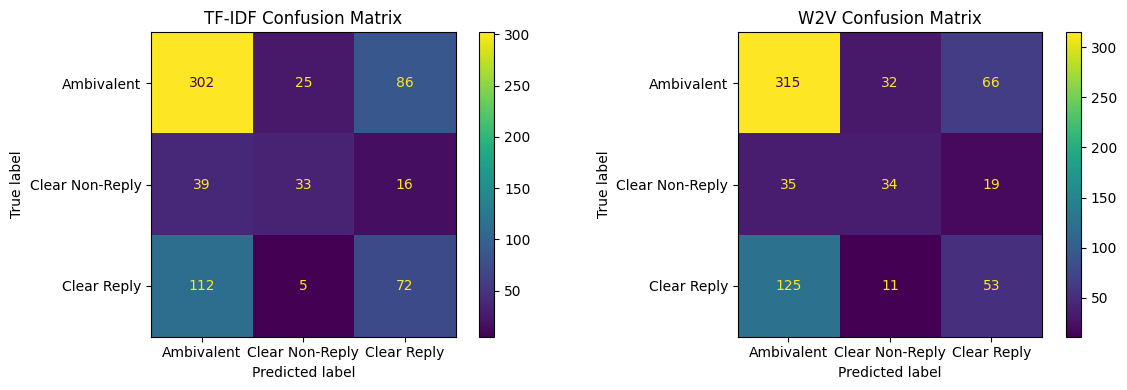

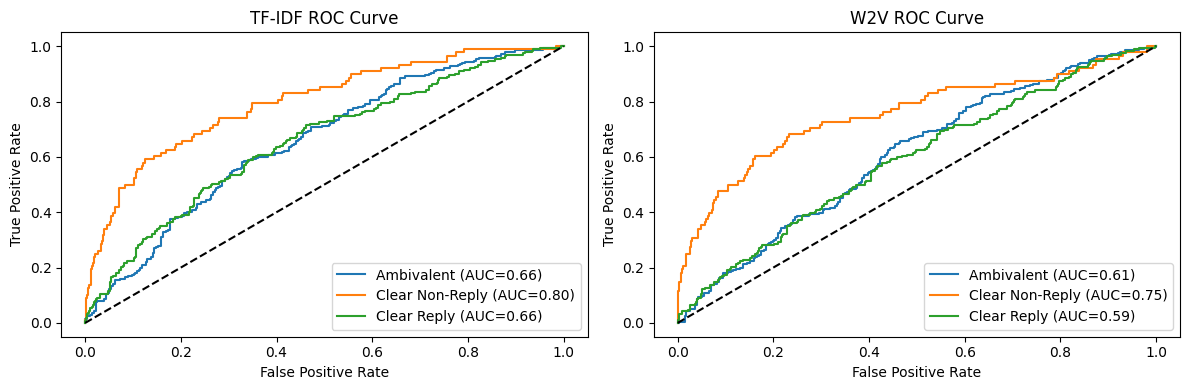

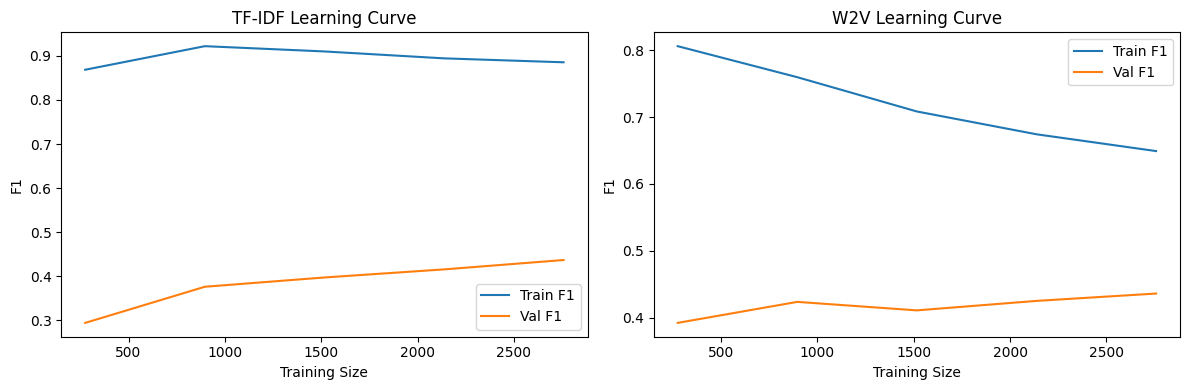

In [16]:
# Plots

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TF-IDF
cm_tfidf = confusion_matrix(y_val_tfidf, y_pred_tfidf)
ConfusionMatrixDisplay(cm_tfidf, display_labels=le.classes_).plot(ax=axes[0])
axes[0].set_title("TF-IDF Confusion Matrix")

# W2V
cm_w2v = confusion_matrix(y_val_w2v, y_pred_w2v)
ConfusionMatrixDisplay(cm_w2v, display_labels=le.classes_).plot(ax=axes[1])
axes[1].set_title("W2V Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches='tight', dpi=150)
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = [0, 1, 2]
y_val_bin_tfidf = label_binarize(y_val_tfidf, classes=classes)
y_val_bin_w2v   = label_binarize(y_val_w2v,   classes=classes)
y_score_tfidf   = model_tfidf.predict_proba(X_val_tfidf)
y_score_w2v     = model_w2v.predict_proba(X_val_w2v)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TF-IDF
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_val_bin_tfidf[:, i], y_score_tfidf[:, i])
    axes[0].plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
axes[0].plot([0,1], [0,1], 'k--')
axes[0].set_title("TF-IDF ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# W2V
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_val_bin_w2v[:, i], y_score_w2v[:, i])
    axes[1].plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title("W2V ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("roc_curve.png", bbox_inches='tight', dpi=150)
plt.show()

# Learning Curve
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TF-IDF
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(C=5, solver='lbfgs', class_weight="balanced", max_iter=5000, random_state=42),
    X_tfidf, train_df["label"], cv=5, scoring='f1_macro', n_jobs=-1
)
axes[0].plot(train_sizes, train_scores.mean(axis=1), label="Train F1")
axes[0].plot(train_sizes, val_scores.mean(axis=1),   label="Val F1")
axes[0].set_title("TF-IDF Learning Curve")
axes[0].set_xlabel("Training Size")
axes[0].set_ylabel("F1")
axes[0].legend()

# W2V
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(C=10, solver='liblinear', class_weight="balanced", max_iter=5000, random_state=42),
    X_w2v, train_df["label"], cv=5, scoring='f1_macro', n_jobs=-1
)
axes[1].plot(train_sizes, train_scores.mean(axis=1), label="Train F1")
axes[1].plot(train_sizes, val_scores.mean(axis=1),   label="Val F1")
axes[1].set_title("W2V Learning Curve")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("F1")
axes[1].legend()

plt.tight_layout()
plt.savefig("learning_curve.png", bbox_inches='tight', dpi=150)
plt.show()

In [17]:
# Submission CSV
submission = pd.DataFrame({
    'Id': test_df['index'],
    'Predicted': le.inverse_transform(model_tfidf.predict(X_test_tfidf))
})
submission.to_csv('submission.csv', index=False)
print(submission.head())
print("Submission shape:", submission.shape)

   Id    Predicted
0   0   Ambivalent
1   1   Ambivalent
2   2  Clear Reply
3   3   Ambivalent
4   4  Clear Reply
Submission shape: (308, 2)
